In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 54.8 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.



                 RAW EEG DATA
Number of channels : 64
Sampling frequency : 160.0 Hz
Duration           : 60.99375 seconds

Channel names:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


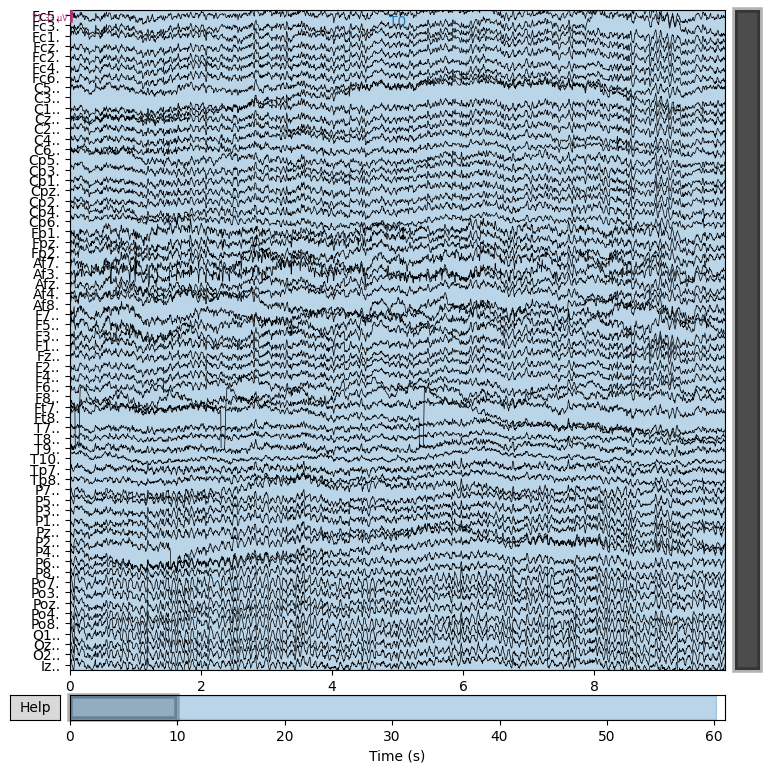


                EEG CHANNELS ONLY
Number of EEG channels: 64

EEG channels:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


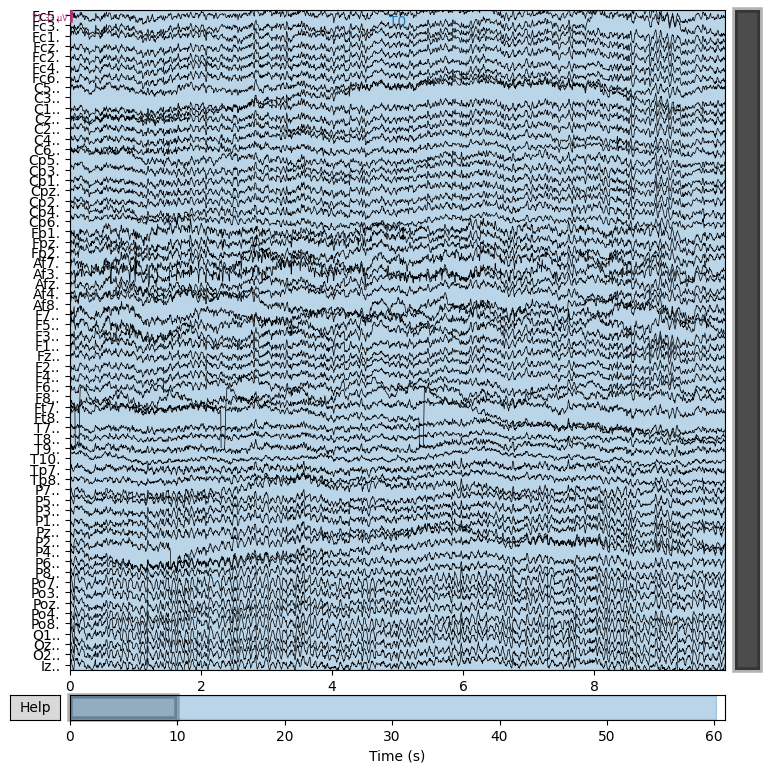


Channel selected for detailed plots:
Fc5.

              AVERAGE REFERENCE
Average reference applied successfully.


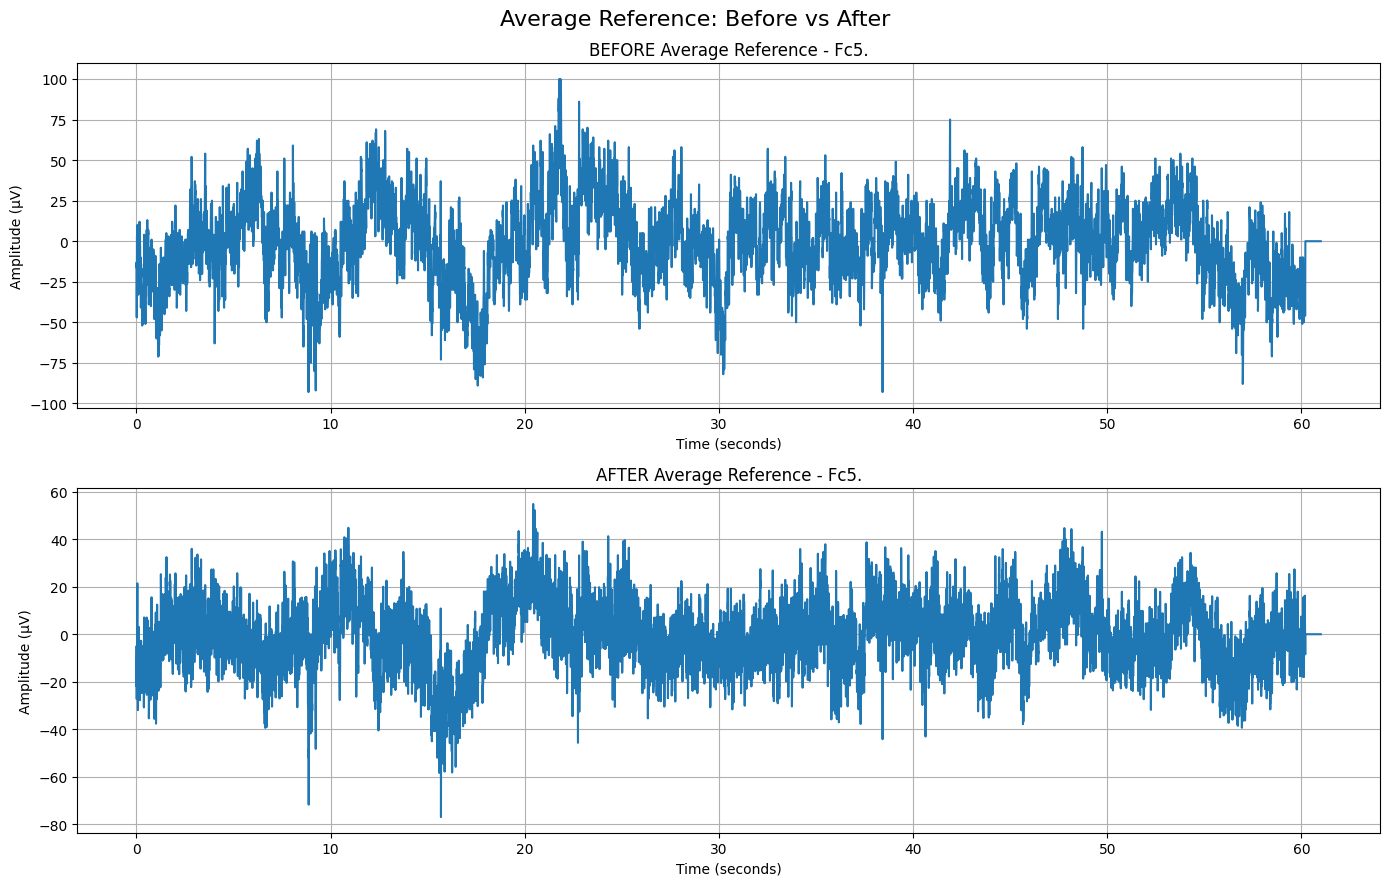


                 NOTCH FILTER
Notch frequency: 50 Hz


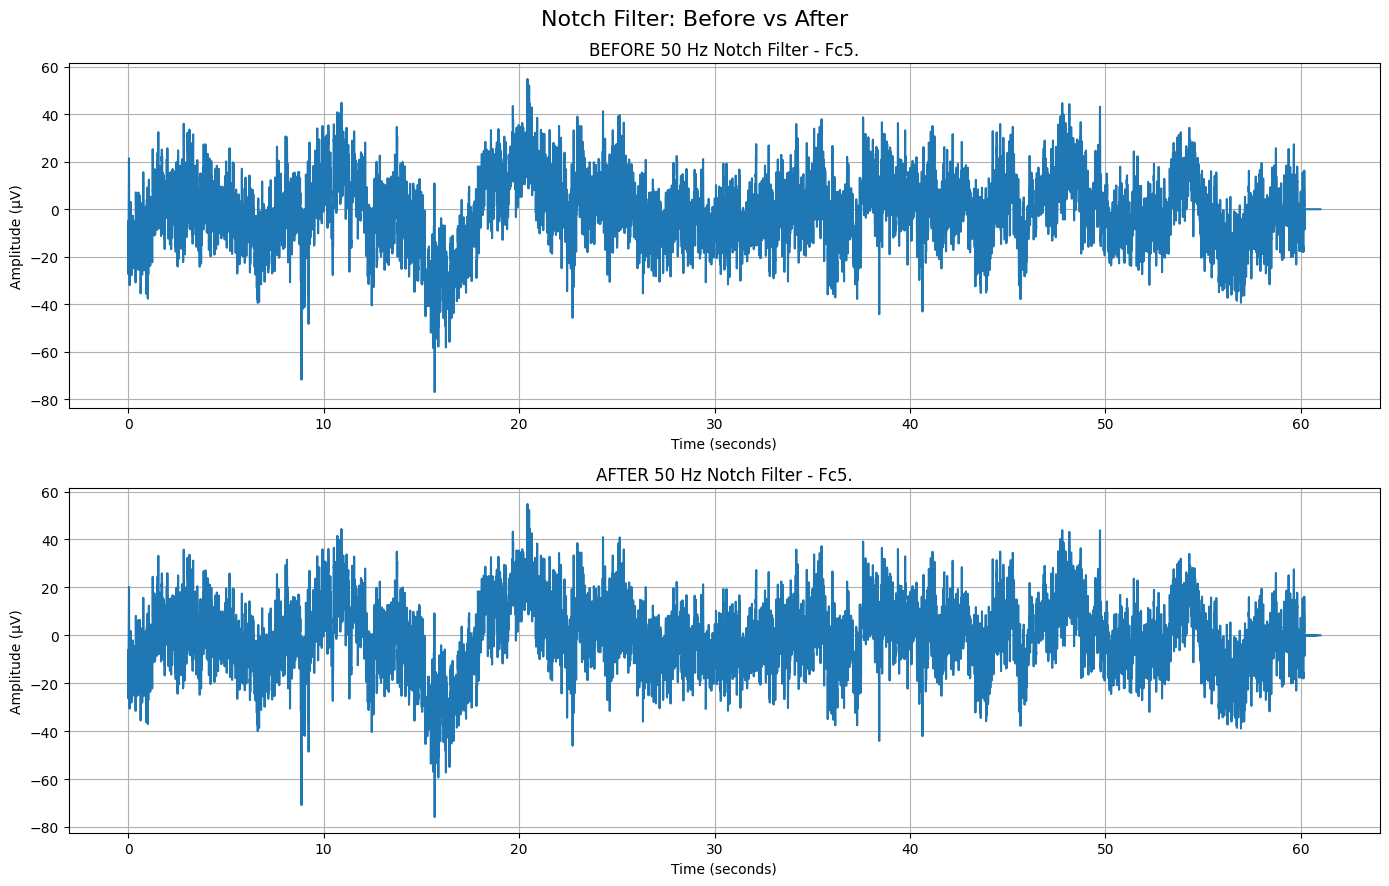


              BAND-PASS FILTER
Band-pass range: 1-40 Hz


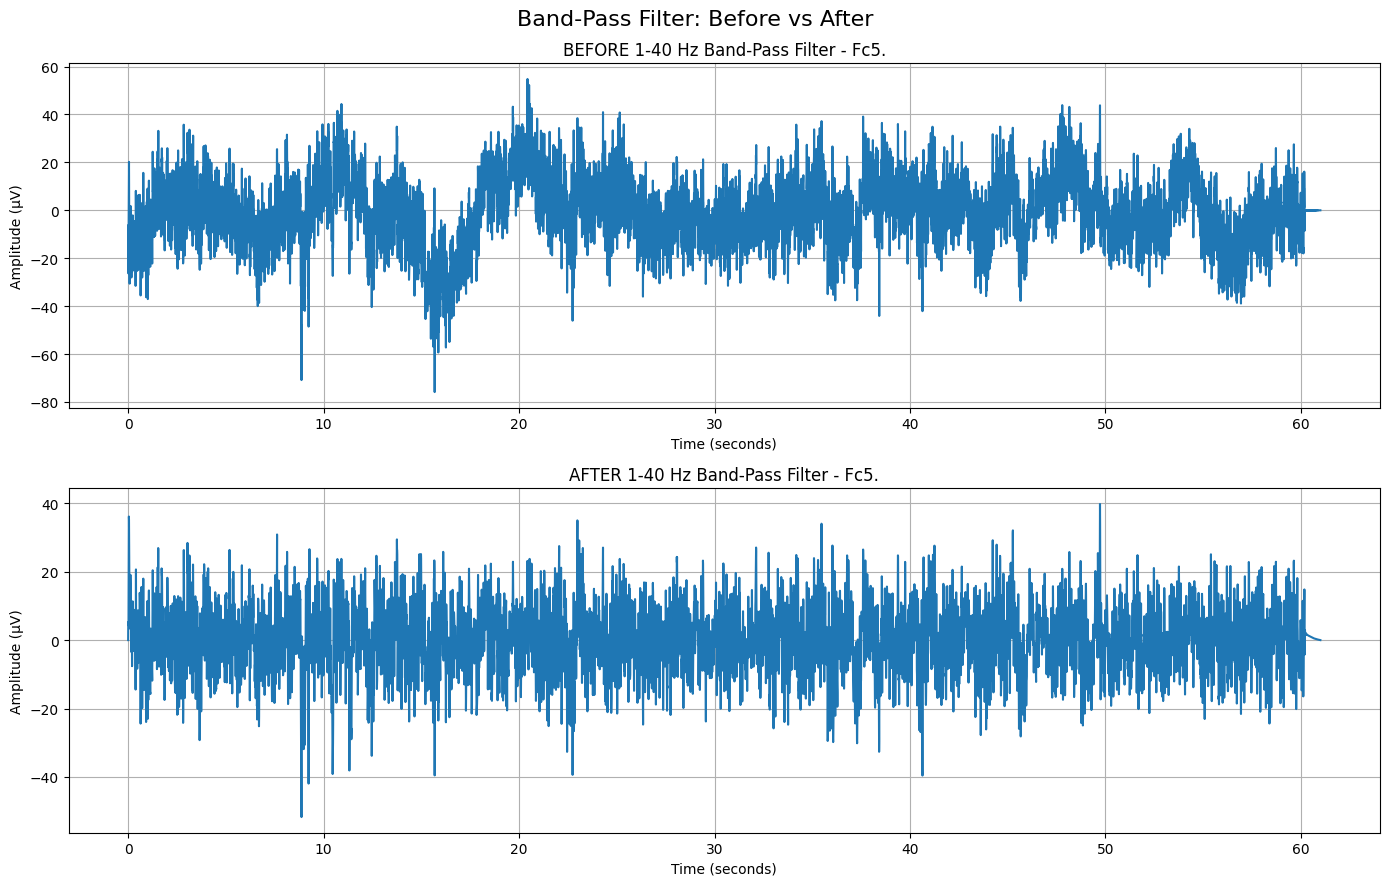


              ARTIFACT DETECTION
Artifact threshold: 150.0 µV
Number of artifact samples: 75
Artifact percentage: 0.77%


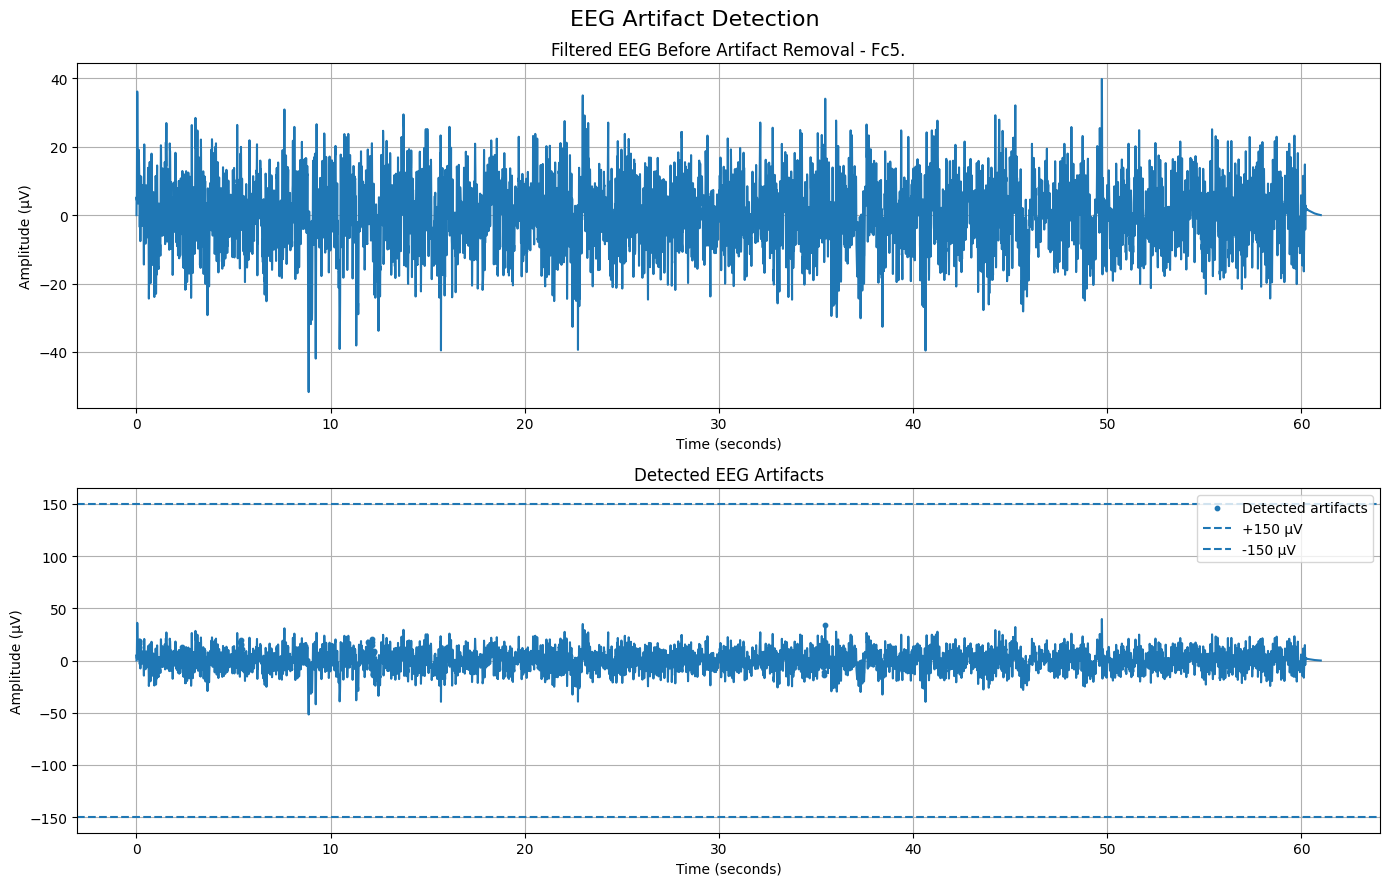


                    EPOCHING
Epoch duration: 2.0 seconds
Number of epochs: 30
Epoch data shape: (30, 64, 320)

             ARTIFACT REJECTION
Epochs before rejection: 30
Epochs after rejection: 21
Removed epochs: 9


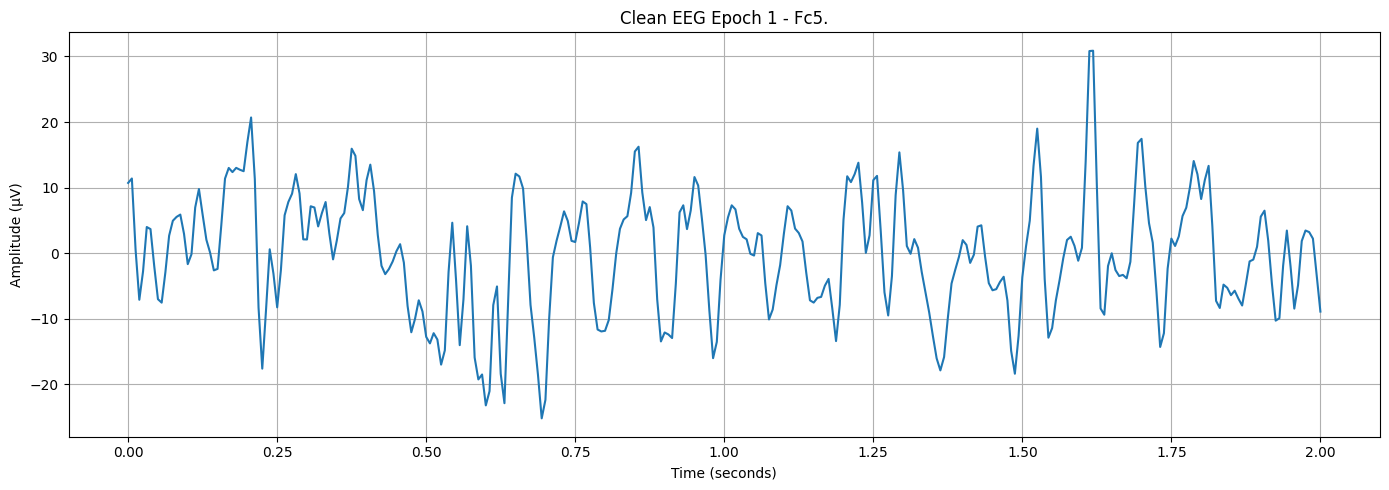


          BEFORE NORMALIZATION
Data shape: (21, 64, 321)
Mean: 8.041849669822759e-24
Standard deviation: 1.392297414391321e-05

           AFTER NORMALIZATION
Normalized mean: 5.303246015862638e-18
Normalized standard deviation: 0.9999999999999998


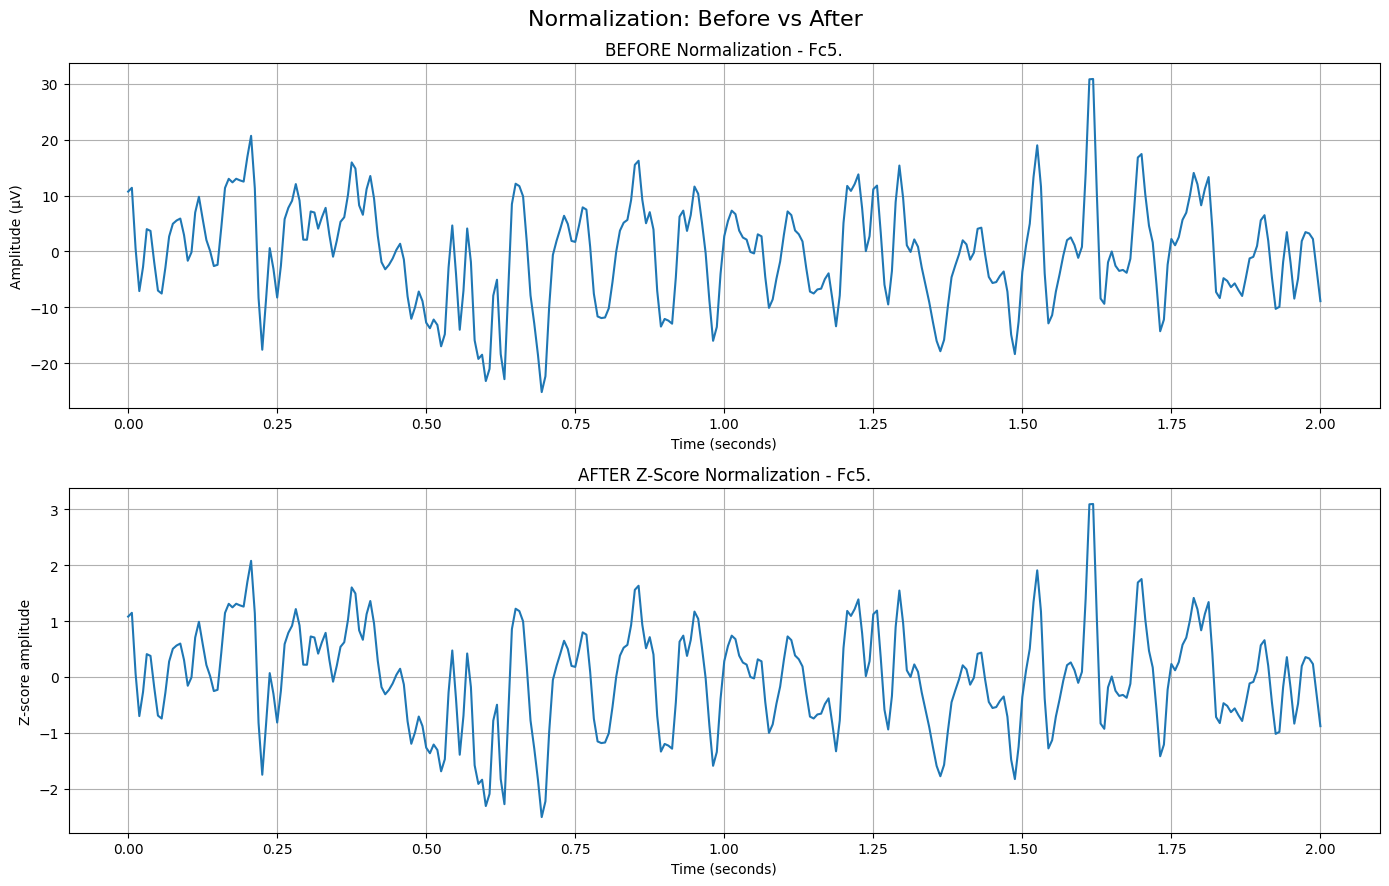


             FINAL EEG DATASET
Number of epochs: 21
Number of channels: 64
Samples per epoch: 321
Sampling frequency: 160.0 Hz


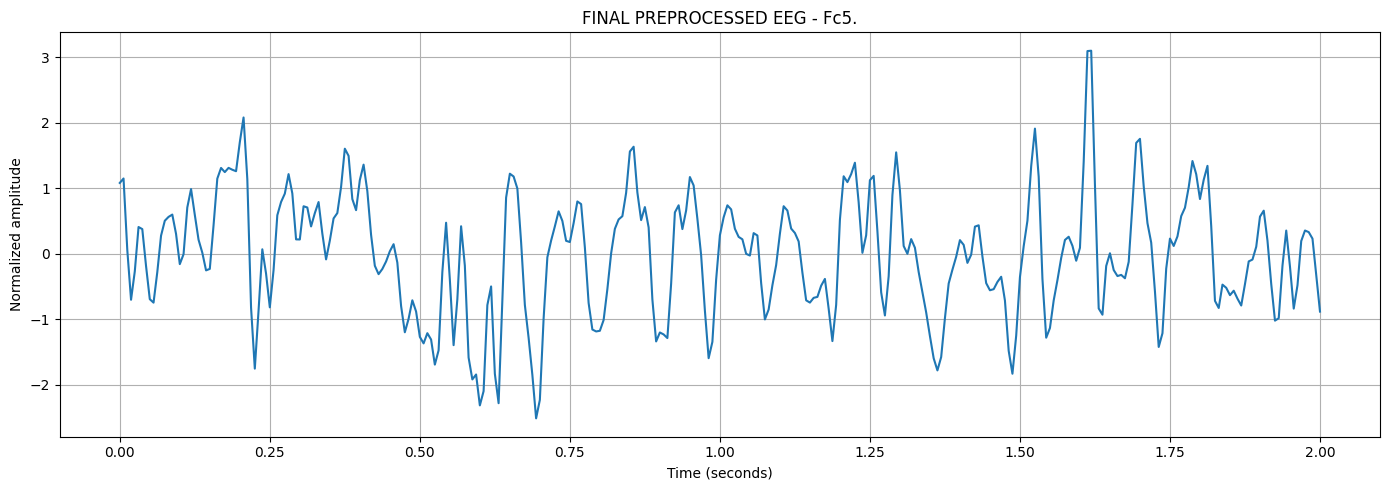

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.

          PREPROCESSING COMPLETED
Saved: S004R02_preprocessed-epo.fif
Saved: S004R02_preprocessed.npy

Generated figures:
1. 01_average_reference_before_after.png
2. 02_notch_filter_before_after.png
3. 03_bandpass_filter_before_after.png
4. 04_artifact_detection.png
5. 05_clean_epoch.png
6. 06_normalization_before_after.png
7. 07_final_preprocessed_EEG.png


In [6]:

# ================================================================
# EEG PREPROCESSING PIPELINE
# Dataset: S004R02.edf
#
# Output:
# 1. Raw EEG - All channels
# 2. EEG channels only
# 3. Before vs After Average Reference
# 4. Before vs After Notch Filter
# 5. Before vs After Band-pass Filter
# 6. Artifact Detection
# 7. Epoching
# 8. Before vs After Normalization
# 9. Final preprocessed EEG
#
# IMPORTANT:
# "Before" and "After" signals are shown in SEPARATE GRAPHS
# but they are placed together in ONE IMAGE (one figure).
# ================================================================


# ================================================================
# 1. IMPORT REQUIRED LIBRARIES
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import mne
import os


# ================================================================
# 2. LOAD THE EDF FILE
# ================================================================

file_path = r"/content/S004R02 (1).edf"

# Read the EDF file
raw = mne.io.read_raw_edf(
    file_path,
    preload=True,
    verbose=False
)

print("\n================================================")
print("                 RAW EEG DATA")
print("================================================")

print("Number of channels :", len(raw.ch_names))
print("Sampling frequency :", raw.info["sfreq"], "Hz")
print("Duration           :", raw.times[-1], "seconds")

print("\nChannel names:")
print(raw.ch_names)


# ================================================================
# 3. PLOT RAW EEG - ALL CHANNELS
# ================================================================

# This is an interactive MNE plot.
# It displays the original EEG before preprocessing.

raw.plot(
    n_channels=len(raw.ch_names),
    duration=10,
    scalings="auto",
    title="RAW EEG - ALL CHANNELS"
)

plt.show()


# ================================================================
# 4. SELECT EEG CHANNELS ONLY
# ================================================================

# Automatically identify EEG channels
eeg_picks = mne.pick_types(
    raw.info,
    eeg=True,
    exclude="bads"
)

# Keep only EEG channels
raw_eeg = raw.copy().pick(eeg_picks)

print("\n================================================")
print("                EEG CHANNELS ONLY")
print("================================================")

print("Number of EEG channels:", len(raw_eeg.ch_names))

print("\nEEG channels:")
print(raw_eeg.ch_names)


# ================================================================
# 5. PLOT EEG CHANNELS ONLY
# ================================================================

raw_eeg.plot(
    n_channels=len(raw_eeg.ch_names),
    duration=10,
    scalings="auto",
    title="EEG CHANNELS ONLY"
)

plt.show()


# ================================================================
# 6. SELECT ONE CHANNEL FOR DETAILED COMPARISON
# ================================================================

# We use the first EEG channel for detailed visualization.
#
# You can change this to a specific channel if required:
#
# channel_to_plot = "C3"
#
# or
#
# channel_to_plot = "C4"

channel_to_plot = raw_eeg.ch_names[0]

print("\nChannel selected for detailed plots:")
print(channel_to_plot)


# ================================================================
# 7. AVERAGE REFERENCE
# ================================================================

# Save the signal BEFORE average reference
raw_before_reference = raw_eeg.copy()

# Apply average reference
raw_after_reference = raw_eeg.copy()

raw_after_reference.set_eeg_reference(
    ref_channels="average",
    projection=False,
    verbose=False
)

print("\n================================================")
print("              AVERAGE REFERENCE")
print("================================================")

print("Average reference applied successfully.")


# ================================================================
# 8. BEFORE AND AFTER AVERAGE REFERENCE
#    ONE IMAGE - TWO SEPARATE GRAPHS
# ================================================================

before_reference_signal = raw_before_reference.get_data(
    picks=[channel_to_plot]
)[0] * 1e6

after_reference_signal = raw_after_reference.get_data(
    picks=[channel_to_plot]
)[0] * 1e6

time = raw_eeg.times


# Create ONE IMAGE containing TWO SEPARATE GRAPHS
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9)
)


# ---------------- BEFORE ----------------

axes[0].plot(
    time,
    before_reference_signal
)

axes[0].set_title(
    f"BEFORE Average Reference - {channel_to_plot}"
)

axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].grid(True)


# ---------------- AFTER ----------------

axes[1].plot(
    time,
    after_reference_signal
)

axes[1].set_title(
    f"AFTER Average Reference - {channel_to_plot}"
)

axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].grid(True)


# Main title
fig.suptitle(
    "Average Reference: Before vs After",
    fontsize=16
)

plt.tight_layout()

# Save the image
plt.savefig(
    "01_average_reference_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 9. NOTCH FILTER
# ================================================================

# Power-line frequency in India = 50 Hz

notch_frequency = 50

# Signal before notch filtering
raw_before_notch = raw_after_reference.copy()

# Apply notch filter
raw_after_notch = raw_after_reference.copy()

raw_after_notch.notch_filter(
    freqs=[notch_frequency],
    verbose=False
)

print("\n================================================")
print("                 NOTCH FILTER")
print("================================================")

print("Notch frequency:", notch_frequency, "Hz")


# ================================================================
# 10. BEFORE AND AFTER NOTCH FILTER
#     ONE IMAGE - TWO SEPARATE GRAPHS
# ================================================================

before_notch_signal = raw_before_notch.get_data(
    picks=[channel_to_plot]
)[0] * 1e6

after_notch_signal = raw_after_notch.get_data(
    picks=[channel_to_plot]
)[0] * 1e6


fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9)
)


# ---------------- BEFORE NOTCH ----------------

axes[0].plot(
    time,
    before_notch_signal
)

axes[0].set_title(
    f"BEFORE 50 Hz Notch Filter - {channel_to_plot}"
)

axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].grid(True)


# ---------------- AFTER NOTCH ----------------

axes[1].plot(
    time,
    after_notch_signal
)

axes[1].set_title(
    f"AFTER 50 Hz Notch Filter - {channel_to_plot}"
)

axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].grid(True)


fig.suptitle(
    "Notch Filter: Before vs After",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "02_notch_filter_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 11. BAND-PASS FILTER
# ================================================================

# Typical EEG band-pass filtering:
#
# Lower cutoff = 1 Hz
# Upper cutoff = 40 Hz

low_frequency = 1
high_frequency = 40


# Save signal BEFORE band-pass filtering
raw_before_bandpass = raw_after_notch.copy()


# Apply band-pass filter
raw_after_bandpass = raw_after_notch.copy()

raw_after_bandpass.filter(
    l_freq=low_frequency,
    h_freq=high_frequency,
    fir_design="firwin",
    verbose=False
)

print("\n================================================")
print("              BAND-PASS FILTER")
print("================================================")

print(
    f"Band-pass range: {low_frequency}-{high_frequency} Hz"
)


# ================================================================
# 12. BEFORE AND AFTER BAND-PASS FILTER
#     ONE IMAGE - TWO SEPARATE GRAPHS
# ================================================================

before_bandpass_signal = raw_before_bandpass.get_data(
    picks=[channel_to_plot]
)[0] * 1e6

after_bandpass_signal = raw_after_bandpass.get_data(
    picks=[channel_to_plot]
)[0] * 1e6


fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9)
)


# ---------------- BEFORE BAND-PASS ----------------

axes[0].plot(
    time,
    before_bandpass_signal
)

axes[0].set_title(
    f"BEFORE 1-40 Hz Band-Pass Filter - {channel_to_plot}"
)

axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].grid(True)


# ---------------- AFTER BAND-PASS ----------------

axes[1].plot(
    time,
    after_bandpass_signal
)

axes[1].set_title(
    f"AFTER 1-40 Hz Band-Pass Filter - {channel_to_plot}"
)

axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].grid(True)


fig.suptitle(
    "Band-Pass Filter: Before vs After",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "03_bandpass_filter_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 13. ARTIFACT DETECTION
# ================================================================

# Artifact threshold
#
# If the EEG amplitude exceeds +/-150 µV,
# the sample is considered potentially contaminated.

artifact_threshold = 150e-6

filtered_data = raw_after_bandpass.get_data()


# Find samples where ANY channel exceeds threshold
artifact_mask = np.any(
    np.abs(filtered_data) > artifact_threshold,
    axis=0
)


# Calculate percentage of artifact samples
artifact_percentage = (
    np.sum(artifact_mask)
    /
    len(artifact_mask)
) * 100


print("\n================================================")
print("              ARTIFACT DETECTION")
print("================================================")

print(
    "Artifact threshold:",
    artifact_threshold * 1e6,
    "µV"
)

print(
    "Number of artifact samples:",
    np.sum(artifact_mask)
)

print(
    f"Artifact percentage: {artifact_percentage:.2f}%"
)


# ================================================================
# 14. ARTIFACT DETECTION GRAPH
# ================================================================

artifact_signal = raw_after_bandpass.get_data(
    picks=[channel_to_plot]
)[0] * 1e6

artifact_times = time[artifact_mask]

artifact_values = artifact_signal[artifact_mask]


fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9)
)


# ---------------- SIGNAL ----------------

axes[0].plot(
    time,
    artifact_signal
)

axes[0].set_title(
    f"Filtered EEG Before Artifact Removal - {channel_to_plot}"
)

axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].grid(True)


# ---------------- DETECTED ARTIFACTS ----------------

axes[1].plot(
    time,
    artifact_signal
)

if len(artifact_times) > 0:

    axes[1].scatter(
        artifact_times,
        artifact_values,
        s=10,
        label="Detected artifacts"
    )

axes[1].axhline(
    150,
    linestyle="--",
    label="+150 µV"
)

axes[1].axhline(
    -150,
    linestyle="--",
    label="-150 µV"
)

axes[1].set_title(
    "Detected EEG Artifacts"
)

axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude (µV)")

axes[1].legend()
axes[1].grid(True)


fig.suptitle(
    "EEG Artifact Detection",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "04_artifact_detection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 15. EPOCHING
# ================================================================

# Create fixed-length epochs.
#
# Here each epoch is 2 seconds long.

epoch_duration = 2.0

epochs = mne.make_fixed_length_epochs(
    raw_after_bandpass,
    duration=epoch_duration,
    overlap=0,
    preload=True,
    reject_by_annotation=False,
    verbose=False
)


print("\n================================================")
print("                    EPOCHING")
print("================================================")

print(
    "Epoch duration:",
    epoch_duration,
    "seconds"
)

print(
    "Number of epochs:",
    len(epochs)
)

print(
    "Epoch data shape:",
    epochs.get_data().shape
)


# ================================================================
# 16. ARTIFACT REJECTION FROM EPOCHS
# ================================================================

# Remove epochs where any EEG channel exceeds
# +/-150 µV.

epochs_clean = mne.Epochs(
    raw_after_bandpass,
    events=epochs.events,
    event_id=None,
    tmin=0,
    tmax=epoch_duration,
    baseline=None,
    preload=True,
    reject={
        "eeg": artifact_threshold
    },
    reject_by_annotation=False,
    verbose=False
)


print("\n================================================")
print("             ARTIFACT REJECTION")
print("================================================")

print(
    "Epochs before rejection:",
    len(epochs)
)

print(
    "Epochs after rejection:",
    len(epochs_clean)
)

print(
    "Removed epochs:",
    len(epochs) - len(epochs_clean)
)


# ================================================================
# 17. DISPLAY ONE CLEAN EPOCH
# ================================================================

epoch_number = 0

channel_number = 0

clean_epoch_signal = epochs_clean.get_data()[
    epoch_number,
    channel_number,
    :
] * 1e6


fig = plt.figure(
    figsize=(14, 5)
)

plt.plot(
    epochs_clean.times,
    clean_epoch_signal
)

plt.title(
    f"Clean EEG Epoch {epoch_number + 1} - "
    f"{epochs_clean.ch_names[channel_number]}"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "05_clean_epoch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 18. DATA BEFORE NORMALIZATION
# ================================================================

data_before_normalization = (
    epochs_clean.get_data()
)


print("\n================================================")
print("          BEFORE NORMALIZATION")
print("================================================")

print(
    "Data shape:",
    data_before_normalization.shape
)

print(
    "Mean:",
    np.mean(data_before_normalization)
)

print(
    "Standard deviation:",
    np.std(data_before_normalization)
)


# ================================================================
# 19. Z-SCORE NORMALIZATION
# ================================================================

# Z-score normalization:
#
# normalized = (signal - mean) / standard deviation
#
# Normalization is performed separately for each channel
# across all epochs and time samples.

mean = np.mean(
    data_before_normalization,
    axis=(0, 2),
    keepdims=True
)

std = np.std(
    data_before_normalization,
    axis=(0, 2),
    keepdims=True
)


# Prevent division by zero
std[std == 0] = 1


# Perform normalization
data_normalized = (
    data_before_normalization - mean
) / std


# ================================================================
# 20. CREATE NORMALIZED EPOCH OBJECT
# ================================================================

epochs_normalized = mne.EpochsArray(
    data_normalized,
    epochs_clean.info.copy(),
    tmin=epochs_clean.tmin,
    verbose=False
)


print("\n================================================")
print("           AFTER NORMALIZATION")
print("================================================")

print(
    "Normalized mean:",
    np.mean(data_normalized)
)

print(
    "Normalized standard deviation:",
    np.std(data_normalized)
)


# ================================================================
# 21. BEFORE AND AFTER NORMALIZATION
#     ONE IMAGE - TWO SEPARATE GRAPHS
# ================================================================

before_normalization_signal = (
    data_before_normalization[
        epoch_number,
        channel_number,
        :
    ]
)

after_normalization_signal = (
    data_normalized[
        epoch_number,
        channel_number,
        :
    ]
)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9)
)


# ---------------- BEFORE NORMALIZATION ----------------

axes[0].plot(
    epochs_clean.times,
    before_normalization_signal * 1e6
)

axes[0].set_title(
    f"BEFORE Normalization - "
    f"{epochs_clean.ch_names[channel_number]}"
)

axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].grid(True)


# ---------------- AFTER NORMALIZATION ----------------

axes[1].plot(
    epochs_normalized.times,
    after_normalization_signal
)

axes[1].set_title(
    f"AFTER Z-Score Normalization - "
    f"{epochs_normalized.ch_names[channel_number]}"
)

axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Z-score amplitude")
axes[1].grid(True)


fig.suptitle(
    "Normalization: Before vs After",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "06_normalization_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 22. FINAL DATASET
# ================================================================

final_data = epochs_normalized.get_data()


print("\n================================================")
print("             FINAL EEG DATASET")
print("================================================")

print(
    "Number of epochs:",
    final_data.shape[0]
)

print(
    "Number of channels:",
    final_data.shape[1]
)

print(
    "Samples per epoch:",
    final_data.shape[2]
)

print(
    "Sampling frequency:",
    epochs_normalized.info["sfreq"],
    "Hz"
)


# ================================================================
# 23. FINAL NORMALIZED EPOCH
# ================================================================

final_signal = final_data[
    epoch_number,
    channel_number,
    :
]


plt.figure(
    figsize=(14, 5)
)

plt.plot(
    epochs_normalized.times,
    final_signal
)

plt.title(
    f"FINAL PREPROCESSED EEG - "
    f"{epochs_normalized.ch_names[channel_number]}"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "07_final_preprocessed_EEG.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 24. SAVE FINAL EEG DATA
# ================================================================

# Save as MNE FIF file

epochs_normalized.save(
    "S004R02_preprocessed-epo.fif",
    overwrite=True
)


# Save as NumPy file

np.save(
    "S004R02_preprocessed.npy",
    final_data
)


print("\n================================================")
print("          PREPROCESSING COMPLETED")
print("================================================")

print(
    "Saved:",
    "S004R02_preprocessed-epo.fif"
)

print(
    "Saved:",
    "S004R02_preprocessed.npy"
)

print("\nGenerated figures:")

print("1. 01_average_reference_before_after.png")
print("2. 02_notch_filter_before_after.png")
print("3. 03_bandpass_filter_before_after.png")
print("4. 04_artifact_detection.png")
print("5. 05_clean_epoch.png")
print("6. 06_normalization_before_after.png")
print("7. 07_final_preprocessed_EEG.png")

